# Project Data Analytics: Bank Marketing Dataset

#### Objective:  To analyze customer and campaign data from the bank marketing dataset to uncover actionable insights that can guide marketing strategies and improve campaign effectiveness.

#### Name: Oyeleso Tawakalt O.	                    Email: tawakaltoyeleso01@gmail.com

#### Prepare the libraries need

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

### Data Wrangling
#### Gathering Data

Data was downloaded from kaggle 

#### Assessing Dataset

In [42]:
# Check the summary of the data and columns

In [43]:
#load dataset 
#Read dataset and save it as bankmarketing_df
bankmarketing_df = pd.read_csv('C:\\Users\\Tawakalt.Oyeleso\\Desktop\\Tawakalt Docs\\Projects\\2026\\Dataset\\data - bank marketing\\bank-full.csv', sep=";")


In [44]:
#View top 5 datasets
print(bankmarketing_df.head(5))

   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  


In [45]:
#Check dataset shape
print(bankmarketing_df.shape)

(45211, 17)


In [94]:
#check column name
print(bankmarketing_df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [47]:
#check data types and non-null counts
bankmarketing_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [48]:
#check statistics of the table bank_marketing_df
bankmarketing_df.describe()

# Summary including categorical
bankmarketing_df.describe(include = 'all')

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
count,45211.000000,45211,45211,45211,45211,45211.000000,45211,45211,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211
unique,NaN,12,3,4,2,NaN,2,2,3,NaN,12,NaN,NaN,NaN,NaN,4,2
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no
freq,NaN,9732,27214,23202,44396,NaN,25130,37967,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922
mean,40.936210,NaN,NaN,NaN,NaN,1362.272058,NaN,NaN,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN
std,10.618762,NaN,NaN,NaN,NaN,3044.765829,NaN,NaN,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,-8019.000000,NaN,NaN,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN
25%,33.000000,NaN,NaN,NaN,NaN,72.000000,NaN,NaN,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN
50%,39.000000,NaN,NaN,NaN,NaN,448.000000,NaN,NaN,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN
75%,48.000000,NaN,NaN,NaN,NaN,1428.000000,NaN,NaN,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN


In [49]:
#check for missing values
print(bankmarketing_df.isnull())

#sum missing values
print(bankmarketing_df.isnull().sum())

         age    job  marital  education  default  balance  housing   loan  \
0      False  False    False      False    False    False    False  False   
1      False  False    False      False    False    False    False  False   
2      False  False    False      False    False    False    False  False   
3      False  False    False      False    False    False    False  False   
4      False  False    False      False    False    False    False  False   
...      ...    ...      ...        ...      ...      ...      ...    ...   
45206  False  False    False      False    False    False    False  False   
45207  False  False    False      False    False    False    False  False   
45208  False  False    False      False    False    False    False  False   
45209  False  False    False      False    False    False    False  False   
45210  False  False    False      False    False    False    False  False   

       contact    day  month  duration  campaign  pdays  previous  poutcome

In [50]:
#checking for duplicates
print(bankmarketing_df.duplicated())

#sum for duplicates
duplicate_values = bankmarketing_df.duplicated().sum()
print(f"Total duplicate values: {duplicate_values}")


0        False
1        False
2        False
3        False
4        False
         ...  
45206    False
45207    False
45208    False
45209    False
45210    False
Length: 45211, dtype: bool
Total duplicate values: 0


### Cleaning Dataset

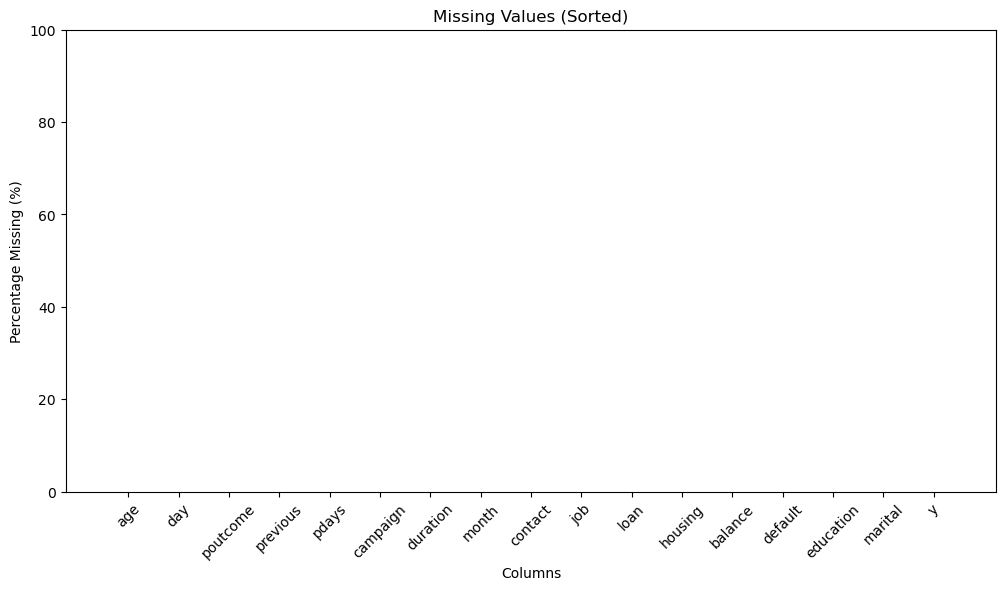

In [51]:
#plotting bar chart for missing values

missing_percentage = bankmarketing_df.isnull().mean() * 100
missing_percentage = missing_percentage.sort_values(ascending = False)

plt.figure(figsize=(12,6))
plt.bar(missing_percentage.index, missing_percentage.values)

plt.xlabel('Columns')
plt.ylabel('Percentage Missing (%)')
plt.title('Missing Values (Sorted)')
plt.xticks(rotation=45)
plt.ylim(0, 100)

plt.show()


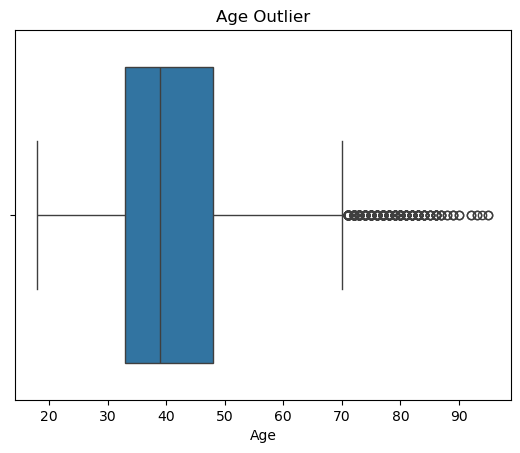

In [52]:
#detecting outlier using histogram and boxplot for age

#using boxplot
sns.boxplot(x='age', data=bankmarketing_df)  # x=column, data=DataFrame
plt.title("Age Outlier")
plt.xlabel("Age")
plt.show()

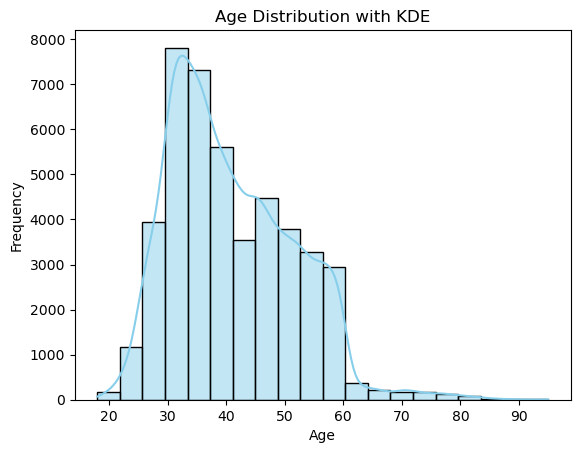

In [53]:
#using histogram

sns.histplot(bankmarketing_df['age'], bins=20, kde=True, color='skyblue')
plt.title("Age Distribution with KDE")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

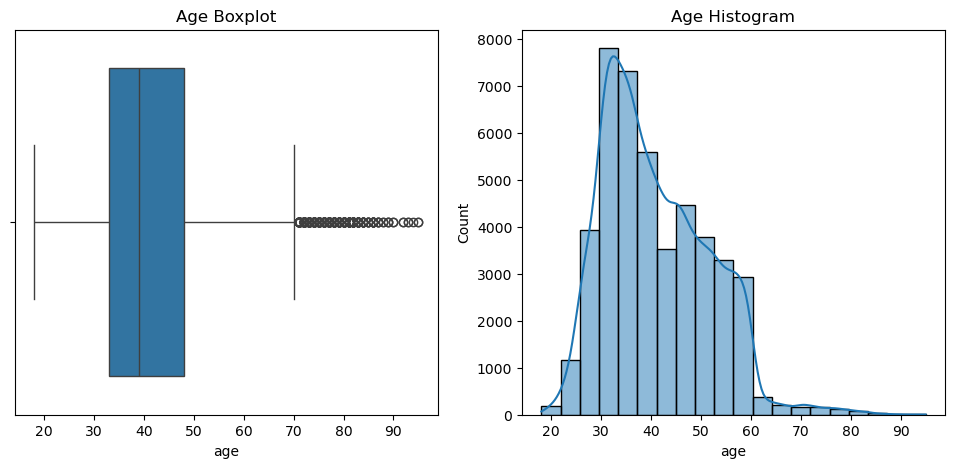

In [54]:
#combining both

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(x='age', data=bankmarketing_df)
plt.title("Age Boxplot")

plt.subplot(1,2,2)
sns.histplot(bankmarketing_df['age'], bins=20, kde=True)
plt.title("Age Histogram")

plt.show()

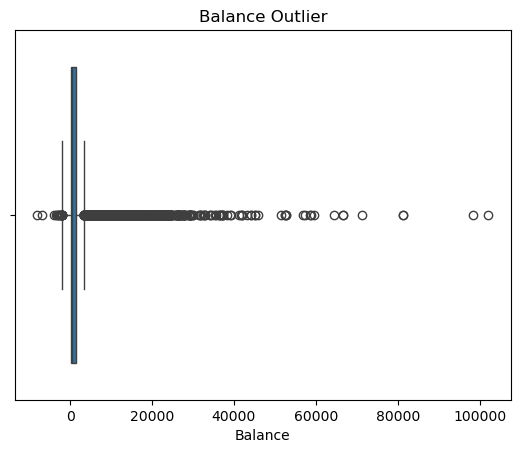

In [55]:
#detecting and visualizing outlier for balance

#using boxplot
sns.boxplot(x = 'balance', data = bankmarketing_df)
plt.title("Balance Outlier")
plt.xlabel("Balance")
plt.show()

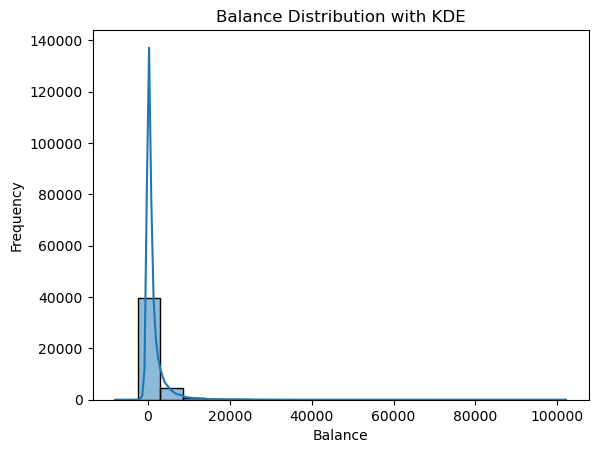

In [56]:
#using histogram 

sns.histplot(bankmarketing_df['balance'], bins = 20, kde = 'True')
plt.title("Balance Distribution with KDE")
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

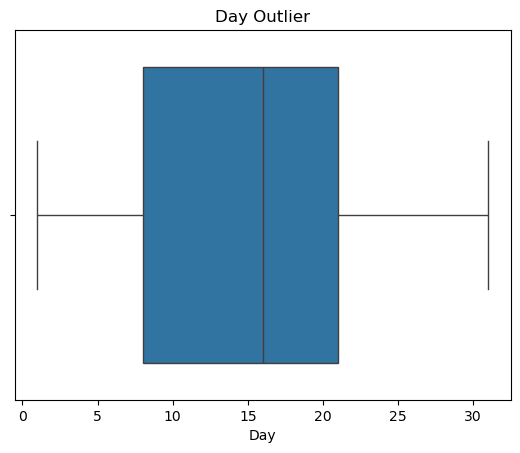

In [57]:
#detecting and visualizing outlier for day

#using boxplot
sns.boxplot(x = 'day', data = bankmarketing_df)
plt.title('Day Outlier')
plt.xlabel('Day')
plt.show()

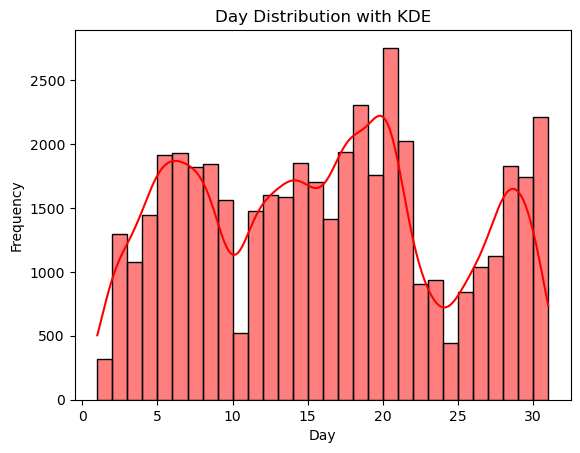

In [58]:
#using histogram

sns.histplot(bankmarketing_df['day'], bins = 30, color = 'red', kde = True)
plt.title('Day Distribution with KDE')
plt.xlabel("Day")
plt.ylabel("Frequency")
plt.show()

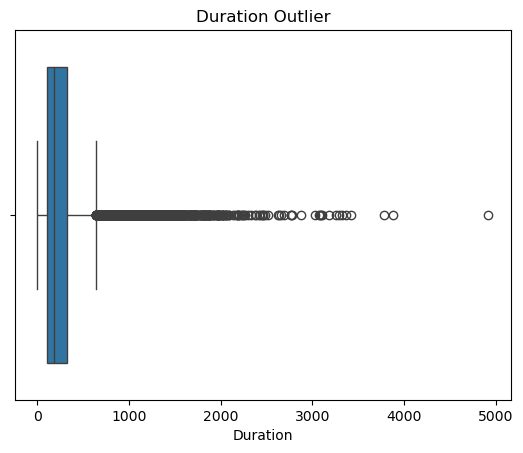

In [59]:
#detecting and visualizing outlier for duration

#using boxplot
sns.boxplot(x = 'duration', data = bankmarketing_df)
plt.title("Duration Outlier")
plt.xlabel("Duration")
plt.show()

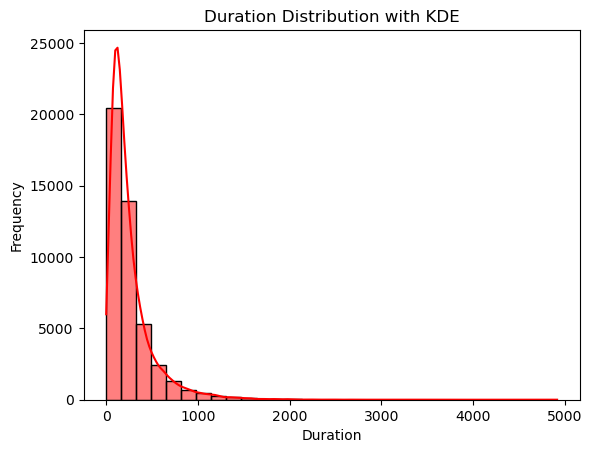

In [60]:
#using histogram

sns.histplot(bankmarketing_df['duration'], color = 'red', bins =30, kde = True)
plt.title("Duration Distribution with KDE")
plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.show()

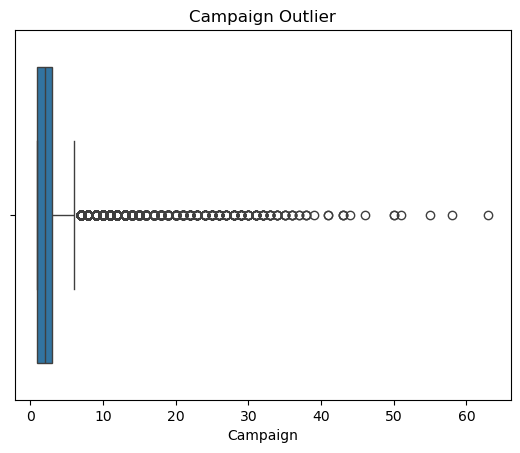

In [61]:
#detecting and visualizing outlier for campaign
#using boxplot

sns.boxplot(x = 'campaign', data = bankmarketing_df)
plt.title("Campaign Outlier")
plt.xlabel("Campaign")
plt.show()

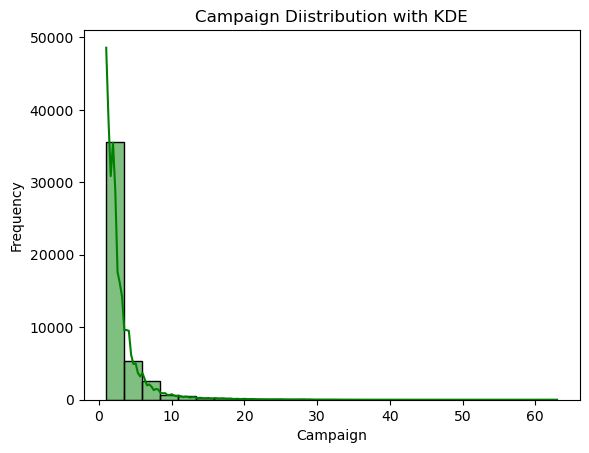

In [62]:
#using histogram

sns.histplot(bankmarketing_df['campaign'], color = 'green', bins = 25, kde = True)
plt.title("Campaign Diistribution with KDE")
plt.xlabel("Campaign")
plt.ylabel("Frequency")
plt.show()

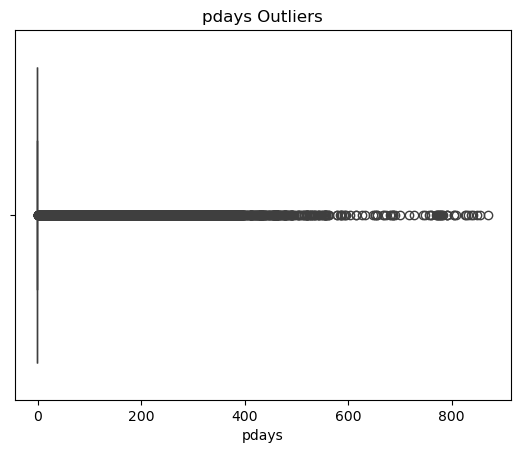

In [63]:
#detecting and visualizing outlier for pdays
#using boxplot

sns.boxplot(x = 'pdays', data = bankmarketing_df)
plt.title("pdays Outliers")
plt.xlabel("pdays")
plt.show()

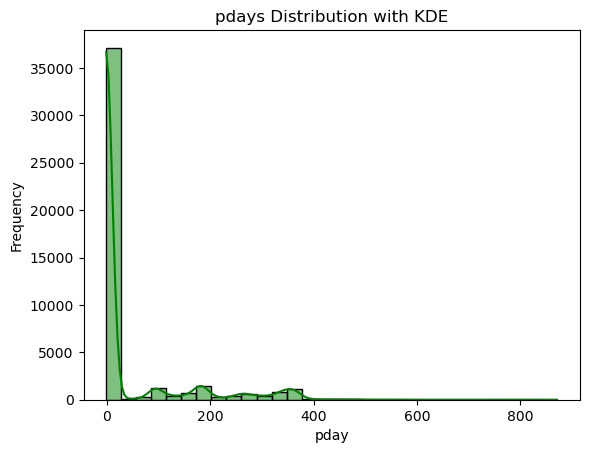

In [64]:
#using histogram

sns.histplot(bankmarketing_df['pdays'], bins = 30, color = 'green', kde = True)
plt.title("pdays Distribution with KDE")
plt.xlabel("pday")
plt.ylabel("Frequency")
plt.show()

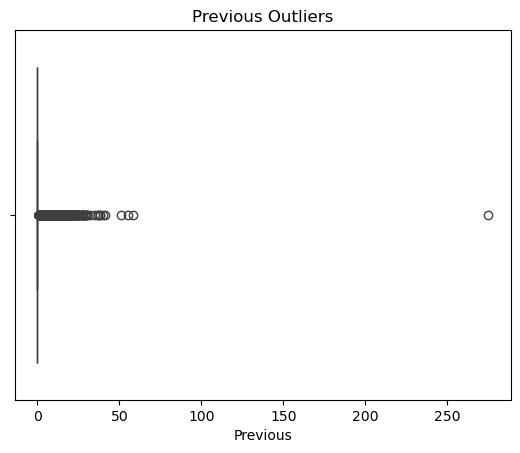

In [65]:
#detecting and visualizing outlier for previous
#using boxplot

sns.boxplot(x = 'previous', data = bankmarketing_df)
plt.title("Previous Outliers")
plt.xlabel("Previous")
plt.show()

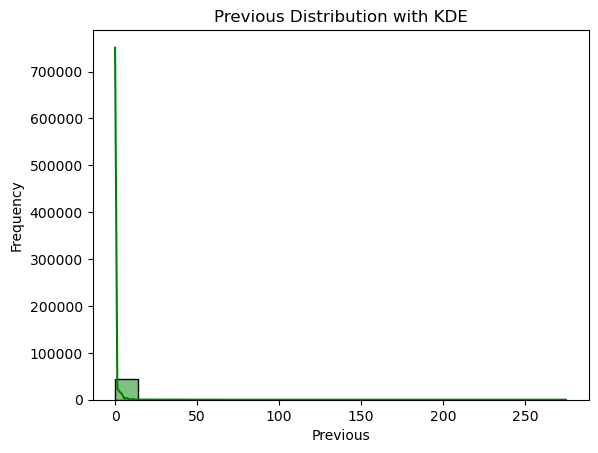

In [66]:
#using histogram

sns.histplot(bankmarketing_df['previous'], bins = 20, color = 'green', kde = True)
plt.title("Previous Distribution with KDE")
plt.xlabel("Previous")
plt.ylabel("Frequency")
plt.show()

In [67]:
#Detecting outliers for age column using IQR method

Q3 = bankmarketing_df['age'].quantile(0.75)
Q1 = bankmarketing_df['age'].quantile(0.25)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = bankmarketing_df[(bankmarketing_df['age'] < lower) | (bankmarketing_df['age'] > upper)]

print(outliers)

       age      job   marital  education default  balance housing loan  \
29158   83  retired   married    primary      no      425      no   no   
29261   75  retired  divorced    primary      no       46      no   no   
29263   75  retired   married    primary      no     3324      no   no   
29322   83  retired   married   tertiary      no     6236      no   no   
29865   75  retired  divorced    primary      no     3881     yes   no   
...    ...      ...       ...        ...     ...      ...     ...  ...   
45163   71  retired   married  secondary      no     2064      no   no   
45191   75  retired  divorced   tertiary      no     3810     yes   no   
45204   73  retired   married  secondary      no     2850      no   no   
45207   71  retired  divorced    primary      no     1729      no   no   
45208   72  retired   married  secondary      no     5715      no   no   

         contact  day month  duration  campaign  pdays  previous poutcome    y  
29158  telephone    2   feb   

In [68]:
#detecting outliers for all column using IQR

numeric_col = bankmarketing_df.select_dtypes(include=np.number).columns


for col in numeric_col:
    Q3 = bankmarketing_df[col].quantile(0.75)
    Q1 = bankmarketing_df[col].quantile(0.25)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = bankmarketing_df[(bankmarketing_df[col] < lower) | (bankmarketing_df[col] > upper)]

    print(f"{col}:{len(outliers)} outliers")

age:487 outliers
balance:4729 outliers
day:0 outliers
duration:3235 outliers
campaign:3064 outliers
pdays:8257 outliers
previous:8257 outliers


##### Handling Outliers for Age

###### Outliers <5%
###### Values are within 70–90 → reasonable adult ages
###### Action:Keep as-is

8.360308326166326

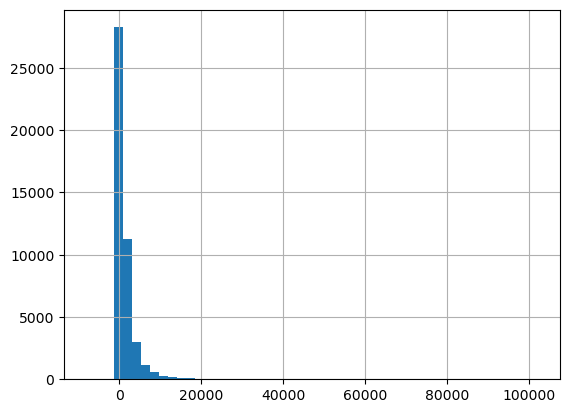

In [69]:
#fixing outliers for balance :4729 outliers

bankmarketing_df['balance'].hist(bins = 50)

bankmarketing_df['balance'].skew()

Skewness after capping: 1.0978021758668195


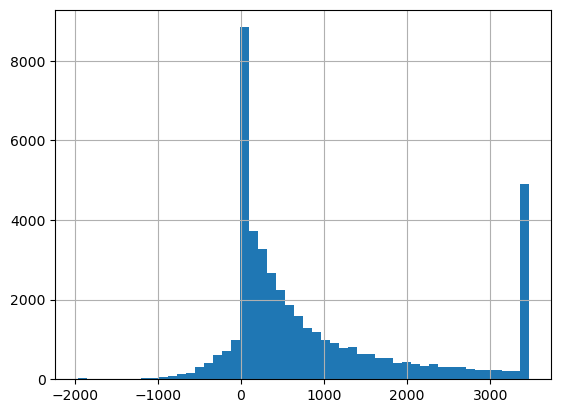

In [70]:
#since balance column value is 8.360308326166326 which is greater than 1, this means the balance distribution is heavily right-skewed

# Applied IQR capping(winsorization)
Q1 = bankmarketing_df['balance'].quantile(0.25)
Q3 = bankmarketing_df['balance'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR 

bankmarketing_df['balance'] = bankmarketing_df['balance'].clip(lower,upper)

bankmarketing_df['balance'].hist(bins=50)

print("Skewness after capping:", bankmarketing_df['balance'].skew())

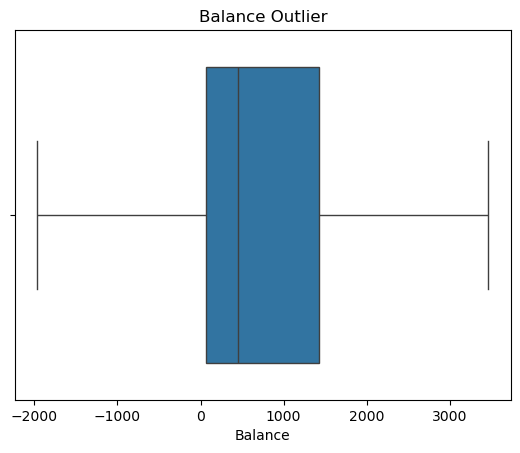

In [75]:
#Replot boxplot
sns.boxplot(x = 'balance', data = bankmarketing_df)
plt.title("Balance Outlier")
plt.xlabel("Balance")
plt.show()

###### Skew reduced → 1.09

###### After capping extreme outliers, the 'balance' column skewness reduced to 1.09.
###### - This is slightly right-skewed (moderate skew). 


3.144318099423456

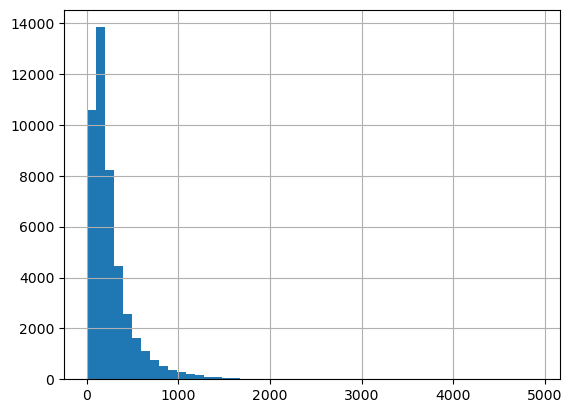

In [80]:
#fixing outliers for duration: 3235 outliers   -   skewed

bankmarketing_df['duration'].hist(bins = 50)

bankmarketing_df['duration'].skew()

Skewness after capping: 1.0375736846374077


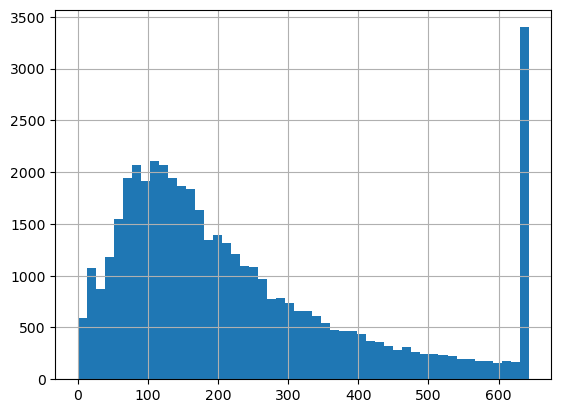

In [86]:
Q3 = bankmarketing_df['duration'].quantile(0.75)
Q1 = bankmarketing_df['duration'].quantile(0.25)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


# Detect outliers
bankmarketing_df['duration'] = bankmarketing_df['duration'].clip(lower, upper)

bankmarketing_df['duration'].hist(bins =50)

print("Skewness after capping:", bankmarketing_df['duration'].skew()) 

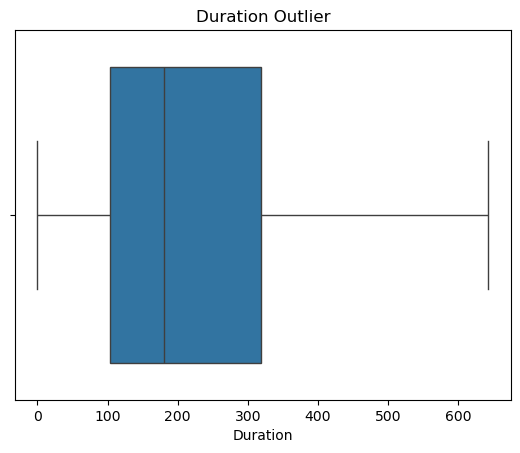

In [87]:
#Replot boxplot
sns.boxplot(x = 'duration', data = bankmarketing_df)
plt.title("Duration Outlier")
plt.xlabel("Duration")
plt.show()

4.898650166179674

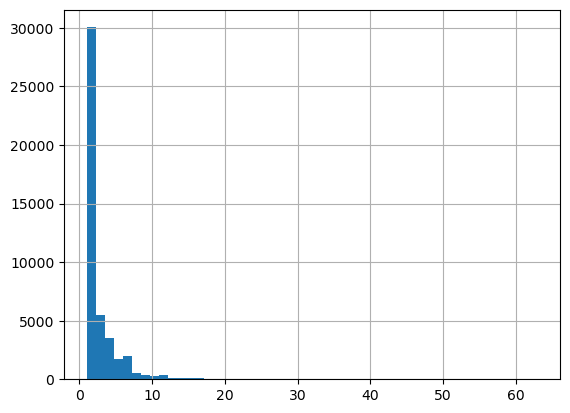

In [89]:
#fixing outliers for campaign: 3064 outliers   -  skewed

bankmarketing_df['campaign'].hist(bins = 50)

bankmarketing_df['campaign'].skew()

Skewness after capping: 1.0991152915287266


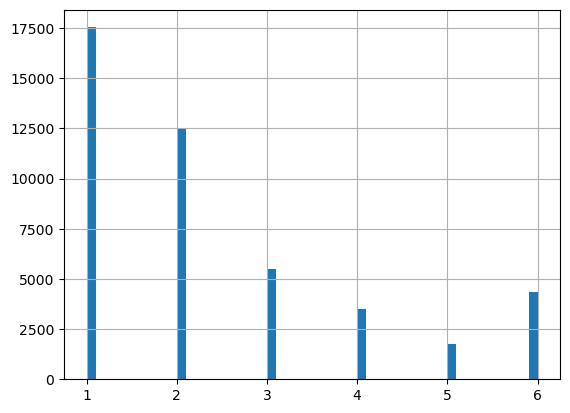

In [90]:
Q3 = bankmarketing_df['campaign'].quantile(0.75)
Q1 = bankmarketing_df['campaign'].quantile(0.25)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR


# Detect outliers
bankmarketing_df['campaign'] = bankmarketing_df['campaign'].clip(lower, upper)

bankmarketing_df['campaign'].hist(bins =50)

print("Skewness after capping:", bankmarketing_df['campaign'].skew()) 

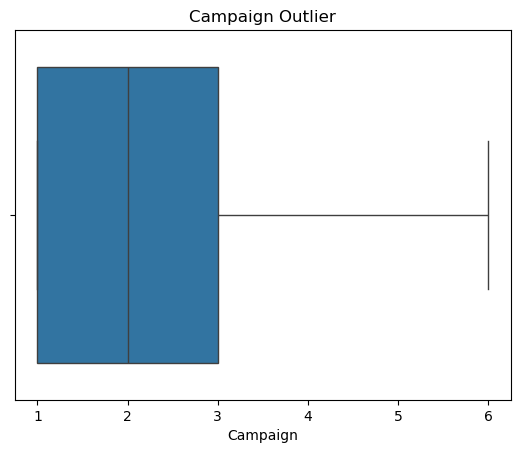

In [95]:
#Replot boxplot
sns.boxplot(x = 'campaign', data = bankmarketing_df)
plt.title("Campaign Outlier")
plt.xlabel("Campaign")
plt.show()

##### Handling Outliers for pdays and previous

##### The values in pdays and previous carry meaningful information rather than being errors:
#####     pdays = -1 → customer was never contacted before
#####     previous = 0 → no prior campaigns
##### Therefore, we will keep these values as they are.


#### Outlier Handling & Skew Reduction:

- Columns 'balance', 'duration', and 'campaign' were initially highly right-skewed with numerous outliers.
- Outliers were detected using the **IQR method** and capped at lower and upper bounds.
- After capping, skewness reduced to:
    - Balance: 1.0978
    - Duration: 1.0376
    - Campaign: 1.0991 
- Distribution patterns across these columns became more symmetric.
- Tree-based models: capped columns are ready for modeling.
- Linear/logistic regression: optional log-transform can be applied if further normalization is needed.
- Original numeric values retained; transformations can be added as new columns if desired.



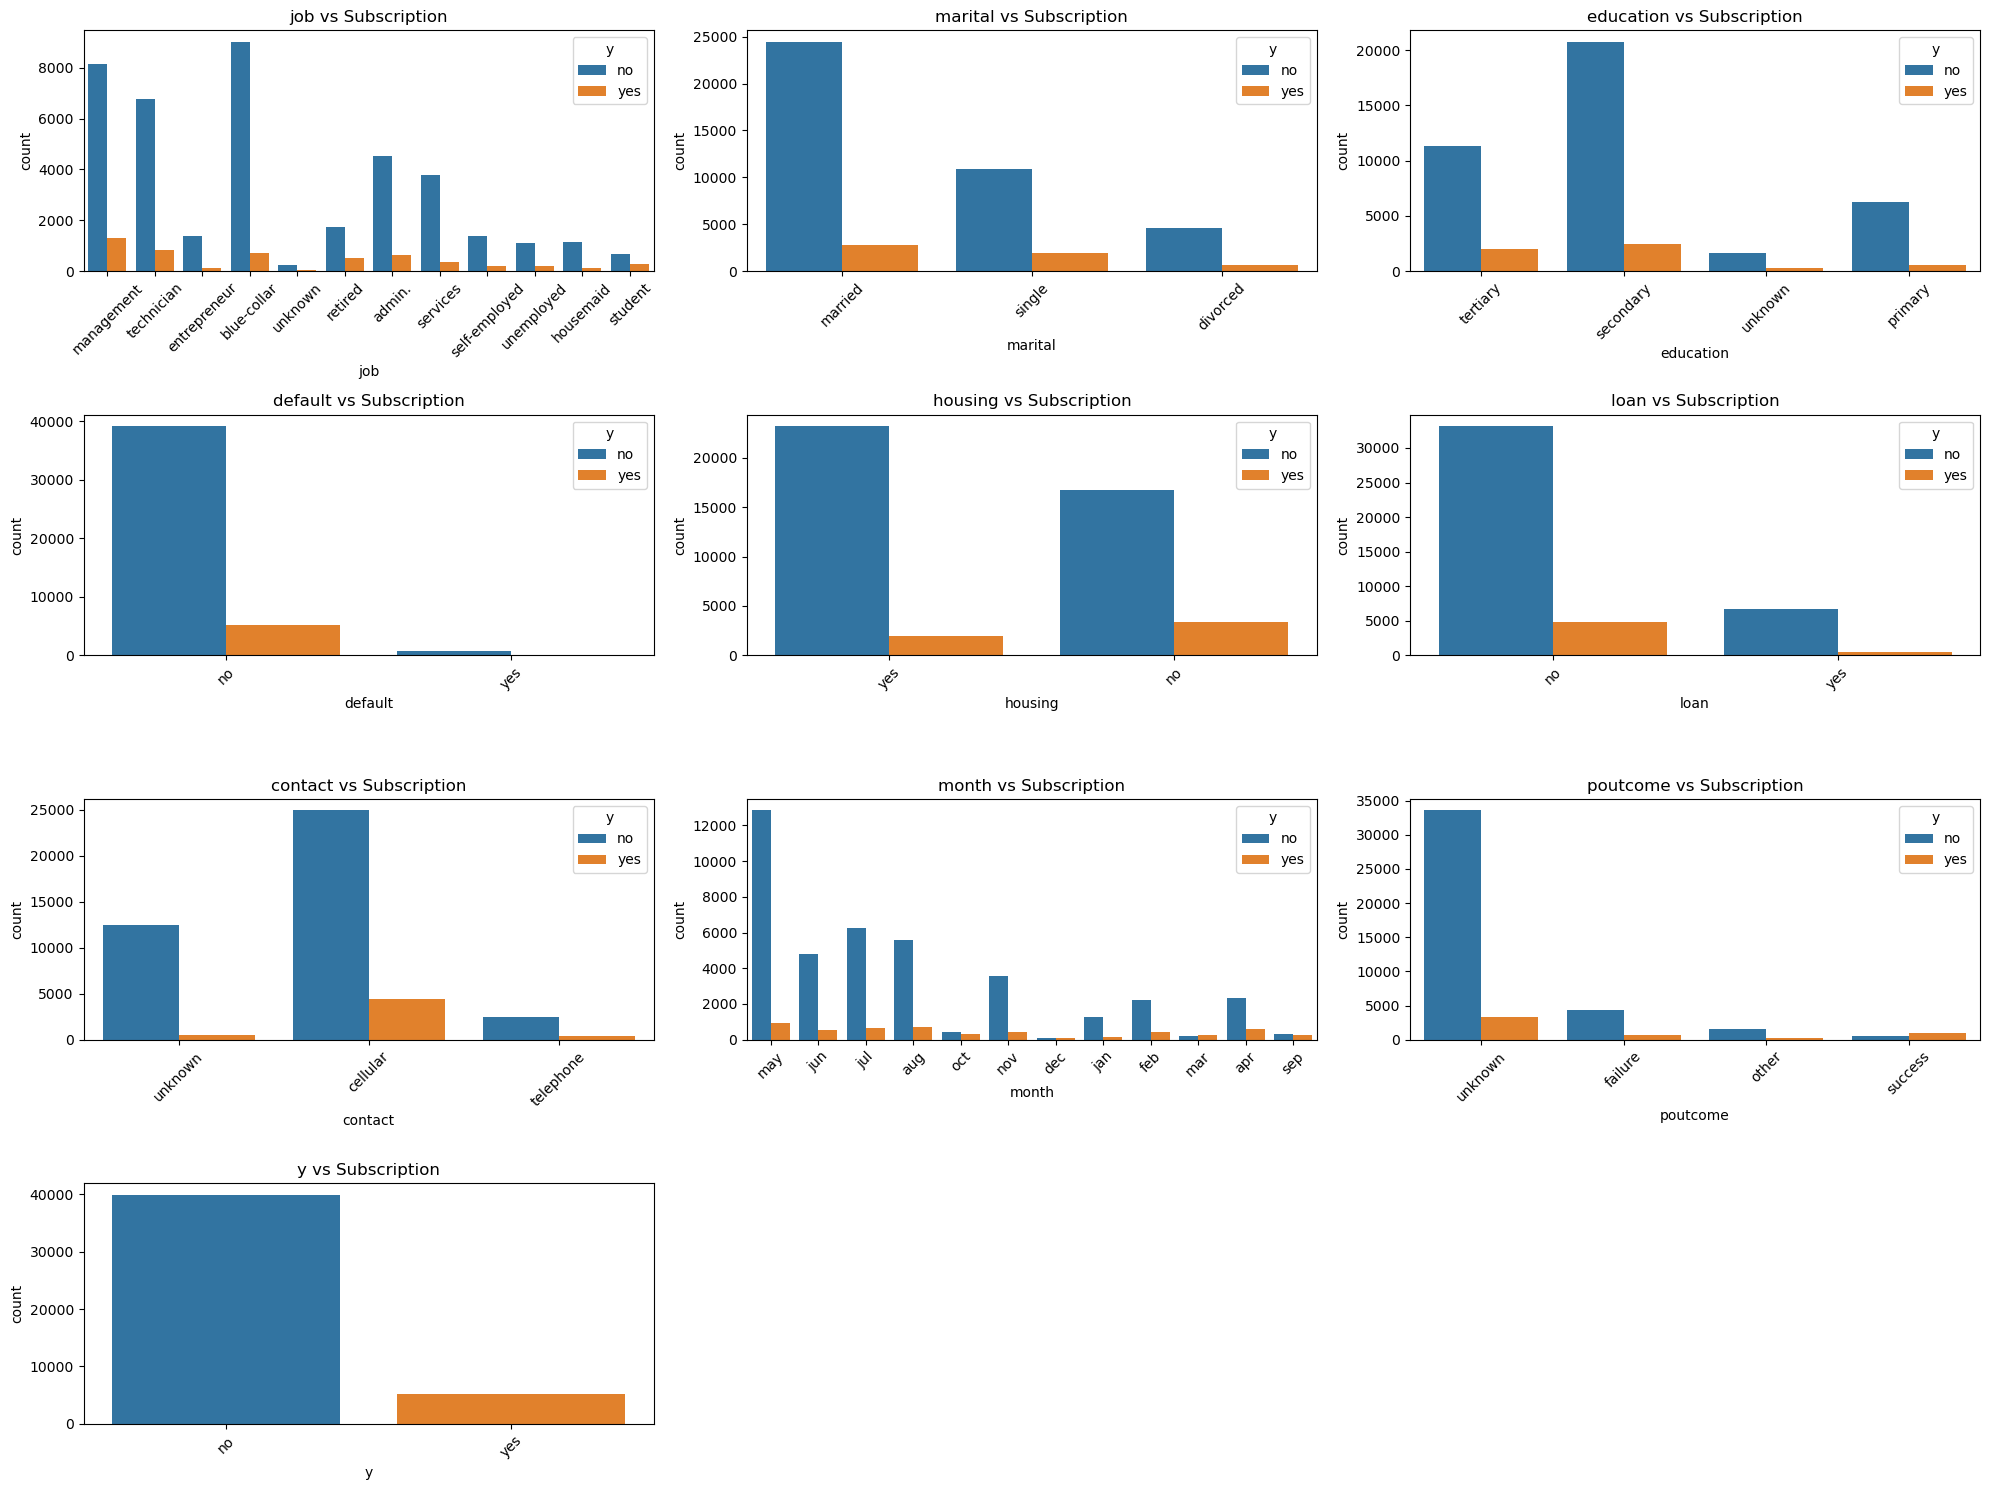

In [113]:
#plotting charts for categorical variables 

#select the categorical columns 
cat_cols = bankmarketing_df.select_dtypes(include = 'object').columns

plt.figure(figsize=(20,15))

for i, col in enumerate(cat_cols):
    plt.subplot(, 3, i+1)  # adjust grid if needed
    sns.countplot(x=col, hue='y', data=bankmarketing_df)
    plt.title(f'{col} vs Subscription')
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show()

#### Insights:

Job:
High subscription: management, technician, retired, students.
Low subscription: housemaid, self-employed, unemployed.
Helps target marketing campaigns toward specific occupations.
    
Marital Status:
Married and single clients subscribe slightly more than divorced.
Useful for demographic segmentation.
    
Education:
Higher education (secondary and tertiary) shows higher subscription.
Unknown education entries can be treated as a separate category for modeling.
    
Default / Housing / Loan:
Clients without personal or housing loans are slightly more likely to subscribe.
Indicates financial burden may affect willingness to invest.
    
Contact Type:
Cellular contacts tend to convert better than telephone.
    
Month:
Some months(May, June, July, August) show slightly higher conversions, suggesting seasonality.
    
Previous Campaign Outcome (poutcome):
Past success dramatically increases subscription likelihood.
    
Clients with “unknown” or “failure” have lower conversion.

#### Exploratory Data Analysis (EDA)

Text(0.5, 1.0, 'Subscription Distribution')

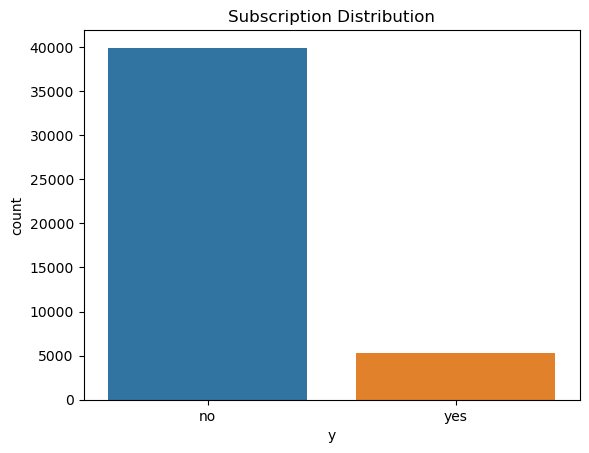

In [115]:
# plotting target distribution

sns.countplot(x = 'y', hue = 'y', data = bankmarketing_df)
plt.title('Subscription Distribution')

#### Insights:
- The majority of clients did not subscribe to a term deposit.
- The dataset is imbalanced, with the minority class ("yes") significantly smaller than the majority class ("no").

<Axes: >

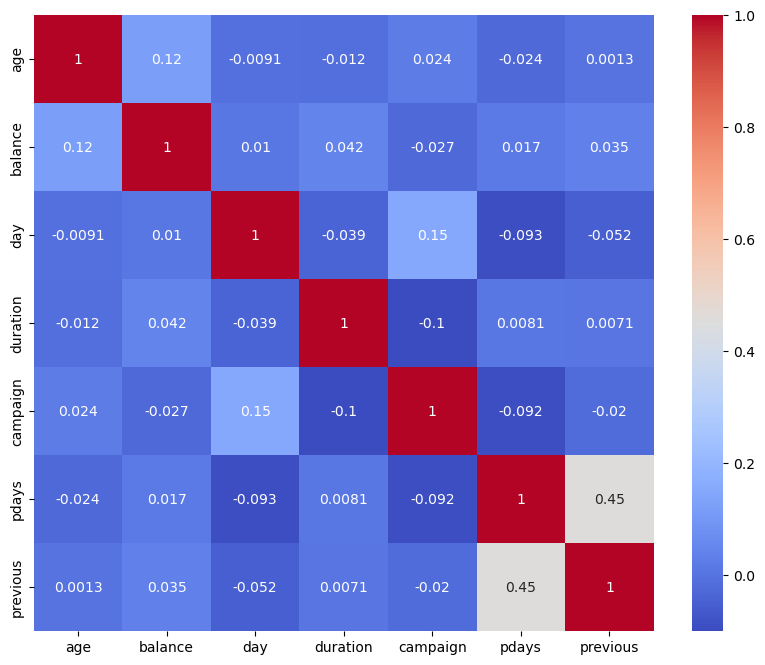

In [100]:
#correlation heatmap - shows relationship between numeric features 

corr = bankmarketing_df.corr(numeric_only = True)
plt.figure(figsize = (10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

#### Insight:
- Overall correlations between numerical features are low, suggesting features are mostly independent.
- No extreme multicollinearity detected, which is favorable for most machine learning models.


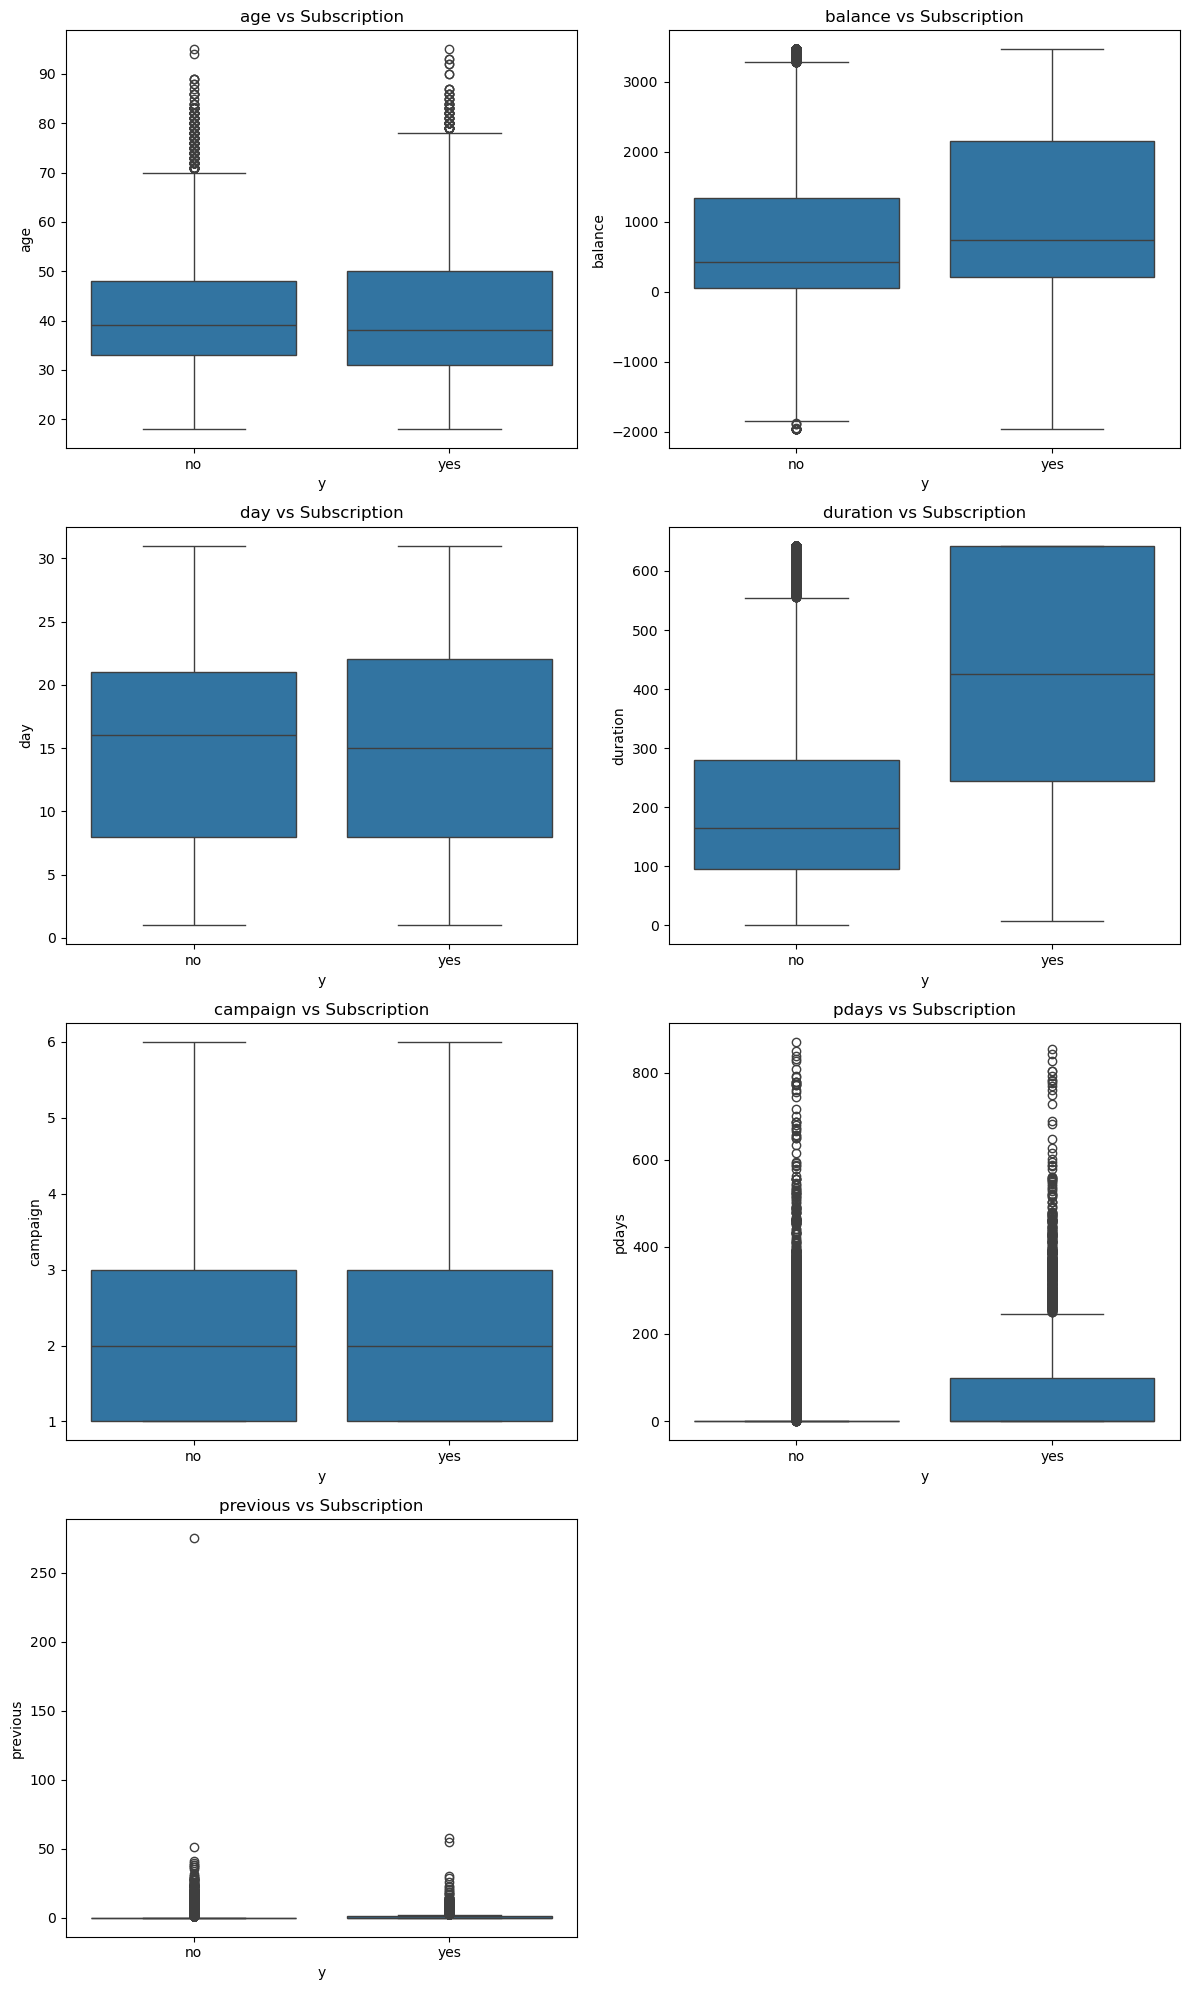

In [118]:
# Numerical vs Target
# Using boxplots:

num_cols = bankmarketing_df.select_dtypes(include='number').columns.tolist()

# Determine rows and columns for subplot grid
n_cols = 2  # number of plots per row
n_rows = (len(num_cols) + n_cols - 1) // n_cols  # ceil division for rows

plt.figure(figsize=(n_cols*6, n_rows*5))  # adjust figure size based on grid

for i, col in enumerate(num_cols):
    plt.subplot(n_rows, n_cols, i+1)
    sns.boxplot(x='y', y=col, data=bankmarketing_df)
    plt.title(f'{col} vs Subscription')

plt.tight_layout()
plt.show()

#### Insights:

Numerical Features vs Target – Insights

- Duration 
Observation: People who subscribe (“yes”) usually have longer call durations.
Insight: Longer conversations indicate more interest; this is one of the strongest predictors.

- Balance 
Observation: Moderate balances tend to subscribe more than very low or very high balances.
Insight: Customers with moderate financial capacity are more likely to invest; extreme outliers don’t contribute much.
    
- Campaign 
Observation: Customers contacted fewer times in this campaign tend to subscribe more.
Insight: Too many repeated contacts may annoy customers and reduce conversion.
    
- Previous 
Observation: Customers with previous contacts, especially if prior campaigns were successful, are more likely to subscribe.
Insight: Past engagement increases trust and likelihood to subscribe.
    
- Pdays 
Observation: Smaller pdays (recent contact) correlate with higher subscription probability.
Insight: Timely follow-up improves conversion.
    
- Age
Observation: Subscription probability is roughly similar across ages, but extreme ages (very young or very old) might subscribe less.
Insight: Middle-aged clients are the main target group.

In [130]:
#class imbalance

counts = bankmarketing_df['y'].value_counts()
print(counts)

percent = bankmarketing_df['y'].value_counts(normalize = True) * 100
print(percent)

y
no     39922
yes     5289
Name: count, dtype: int64
y
no     88.30152
yes    11.69848
Name: proportion, dtype: float64


Conversion rate: 11.70%


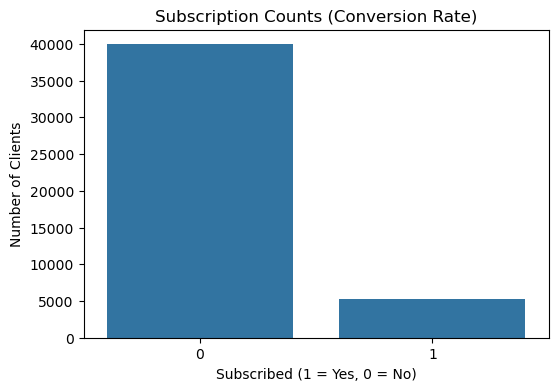

In [139]:
# Conversion rate = % of "yes" (subscribed)
conversion_rate = counts.loc['yes'] / counts.sum() * 100   # use .loc to access by label
print(f"Conversion rate: {conversion_rate:.2f}%")


# Plot subscription counts
plt.figure(figsize=(6,4))
sns.countplot(x='y', data=bankmarketing_df)
plt.title("Subscription Counts (Conversion Rate)")
plt.xlabel("Subscribed (1 = Yes, 0 = No)")
plt.ylabel("Number of Clients")
plt.show()


In [143]:
#conversion rates for categorical variables

#conversion rate by job
bankmarketing_df.groupby('job')['y'].mean().sort_values(ascending=False)

job
student          0.286780
retired          0.227915
unemployed       0.155027
management       0.137556
admin.           0.122027
self-employed    0.118429
unknown          0.118056
technician       0.110570
services         0.088830
housemaid        0.087903
entrepreneur     0.082717
blue-collar      0.072750
Name: y, dtype: float64

#### Insights:
- Highest subscription: Students and retired clients. Possibly more time/flexibility or targeted needs for saving.
- Lowest subscription: Blue-collar, entrepreneurs, housemaids.
- Marketing takeaway: Target campaigns toward high-performing job groups first (student, retired, unemployed).

In [148]:
#conversion rate by education
bankmarketing_df.groupby('education')['y'].mean().sort_values(ascending=False)

education
tertiary     0.150064
unknown      0.135703
secondary    0.105594
primary      0.086265
Name: y, dtype: float64

#### Insights:
- Higher education correlates with higher subscription.
- “Unknown” education surprisingly performs relatively well (could include mixed education types).
- Lower education levels (primary) subscribe less.
- Marketing takeaway: Tailor offers for tertiary-educated clients; consider additional support or incentives for lower education groups.
________________________________________

In [145]:
#conversion rate by marital
bankmarketing_df.groupby('marital')['y'].mean().sort_values(ascending=False)

marital
single      0.149492
divorced    0.119455
married     0.101235
Name: y, dtype: float64

#### Insights:
- Singles have slightly higher subscription rates than married clients.
- Divorced clients are in the middle.
- Marketing takeaway: Consider demographic segmentation — singles might respond better to offers that emphasize flexibility or short-term benefits.

In [146]:
#conversion rate by contact
bankmarketing_df.groupby('contact')['y'].mean().sort_values(ascending=False)

contact
cellular     0.149189
telephone    0.134205
unknown      0.040707
Name: y, dtype: float64

#### Insights:
- Cellular contacts convert better than landline/telephone.
- Unknown contacts are nearly uninformative.
- Marketing takeaway: Prioritize cellular contact campaigns.

In [150]:
#conversion rate by poutcome
bankmarketing_df.groupby('poutcome')['y'].mean().sort_values(ascending=False)

poutcome
success    0.647253
other      0.166848
failure    0.126097
unknown    0.091615
Name: y, dtype: float64

#### Insights:
- Most predictive feature by far: previous success drastically increases likelihood of subscription.
- “Other” and “Failure” outcomes are moderate to low.
- Unknowns have the lowest predictive power.
- Marketing takeaway: Clients with past success should be prioritized.

#### Bank Marketing Dataset Insights

1. Overall Conversion Trends
- Only ~11–11.7% of clients subscribed to the term deposit, highlighting a highly imbalanced dataset.
- Most clients do not convert, indicating low overall campaign efficiency.
- ML models will need class imbalance handling (e.g., SMOTE, class_weight='balanced', or threshold tuning) to avoid bias toward the majority (non-subscribers).

#### Actionable Business Implications
Target high-probability segments: customers with prior successes, longer engagement, higher education, and favorable occupations.
    
Optimize outreach strategy:
- Avoid excessive calls.
- Prefer cellular contact.
- Schedule campaigns during high-conversion months.
    
Machine Learning Modeling:
- Focus on influential features: duration, previous outcomes, and customer segmentation.
- Preprocessing can be mostly straightforward; imbalances are the main challenge.

##### Key Insights

1.	Low Conversion Rate
        - Only ~11.7% of customers subscribed
        - Indicates strong class imbalance and low campaign efficiency

2.	Call Duration is the Strongest Predictor
        - Customers with longer call durations are far more likely to subscribe
        - Suggests engagement during calls is critical

3.	Previous Campaign Success Matters
        - Customers with prior successful interactions have significantly higher conversion rates
        - Indicates trust and familiarity improve outcomes

4.	Over-Contacting Reduces Success
        - Customers contacted too frequently are less likely to subscribe
        - Suggests diminishing returns from repeated outreach

5.	Contact Method Influences Conversion
        - Cellular communication performs better than telephone
        - Highlights importance of communication channel

6.	Customer Profile Patterns
        - Higher subscription rates among:
        - Management, students, retired individuals
        - Customers with higher education
        - Helps refine target segments

7.	Seasonality Exists
        - Certain months show higher conversions
        - Suggests timing plays a role in campaign success


In [ ]:
## Bank Marketing Insights Dashboard
### 📊 Bank Marketing Campaign – Insight Dashboard
### 🎯 Objective

#### Identify key drivers of customer subscription to term deposits and provide actionable marketing and modeling strategies.

##### 📌 Key Metrics
- Conversion Rate: ~11.7%
- Non-Conversion Rate: ~88.3%
- Dataset Challenge: Highly imbalanced target variable

🔍 Top Predictors of Subscription
1. Previous Campaign Outcome (Most Important)
Prior success → very high likelihood of conversion
Failure/Other → moderate impact
Unknown → lowest predictive value

👉 Action: Prioritize customers with past successful interactions

2. Call Duration
Longer calls → higher probability of subscription

👉 Action: Improve call quality, scripts, and engagement strategies

3. Contact Frequency
Too many contacts → lower success rate

👉 Action: Avoid over-contacting; optimize outreach frequency

4. Contact Channel
Cellular > Telephone

👉 Action: Focus more on mobile communication channels

5. Customer Segments

Higher conversion observed among:
- Management
- Students
- Retired individuals
- Higher education levels

👉 Action: Build targeted campaigns for high-performing segments

6. Seasonality
Conversion varies across months

👉 Action: Schedule campaigns during high-performing periods

⚠️ Modeling Considerations
Strong class imbalance → use:
SMOTE
Class weighting (class_weight='balanced')
Threshold tuning
Key features to prioritize:
Duration
Previous outcomes
Campaign interactions
Low correlation across features → simple preprocessing is sufficient
💡 Business Strategy Summary
Focus on high-probability customers (past success + strong profiles)
Improve call engagement quality
Reduce excessive outreach
Use better-performing communication channels
Leverage timing and seasonality
🚀 Final Takeaway

Success is driven by who you contact, how you engage them, and when you reach out.

A data-driven targeting strategy can significantly improve conversion rates and campaign efficiency.